# Healthcare Analytics: End-to-End Patient Readmission Risk Pipeline & ROI Calculator

Welcome to the **Patient Readmission Risk Pipeline & ROI Calculator** showcase. This notebook serves as an interactive presentation layer for our production-grade data pipeline.

## 🩺 Clinical and Business Context
Hospital readmissions (a patient returning to the hospital within 30 days of discharge) are a major challenge in modern healthcare. More importantly, readmissions are highly costly for insurers, healthcare systems, and hospital groups alike, representing a significant burden on medical resources and operational efficiency worldwide.

By leveraging predictive machine learning models, clinical teams can identify high-risk patients **before discharge** and target them with proactive, preventative care programs (e.g., home nurse visits, telephone follow-ups, and specialized medication counseling). 

## 🛠️ Repository Architecture
This project follows **production-grade engineering principles**. The core business logic is modularized inside the `src/` directory:
- `src/ingest.py`: Kaggle dataset downloading and path resolution.
- `src/transform.py`: Raw CSV parsing and relational table normalization, including **Clinical-Domain Feature Engineering**.
- `src/database.py`: Schema population and connection handling with SQLite.
- `src/train.py`: Feature extraction SQL queries (including dynamically calculated SQL features), cross-validated hyperparameter tuning (`GridSearchCV`), and model persistence.
- `src/inference.py`: Score generation and **Business Decision Threshold Optimization** to maximize financial savings.

This notebook imports these modules, performs diagnostic SQL analytics, showcases advanced model evaluation curves (ROC, Precision-Recall, Confusion Matrix), plots feature importance, and analyzes the business ROI of our optimized clinical intervention program.

### Setup & Module Imports

First, we append the parent directory of this notebook to our system path to allow importing modules from `src/` seamlessly.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import joblib

# Add parent directory to system path to import src modules
sys.path.append(os.path.abspath(".."))

print("System path configured successfully. Modules in 'src' are ready to import.")

System path configured successfully. Modules in 'src' are ready to import.


---
## 1. Data Ingestion, Transformation & DB Schema

We ingest raw healthcare transaction records and break down the flat schema into a relational database model with 3 normalized tables, applying **clinical-domain feature engineering** at each step:
1. **`patients`**: Demographics + **`is_elderly`** (age $\ge$ 65, representing patient frailty).
2. **`admissions`**: Administrative records & target label + **`is_high_risk_discharge`** (discharge to nursing facilities or continuous care clinics).
3. **`clinical_details`**: Medical context + **`medication_to_comorbidity_ratio`** (treatment intensity) & **`total_prior_interactions`** (healthcare utilization index).

Additionally, during feature extraction, we compute **`stay_per_comorbidity`** dynamically in a SQL query.

In [2]:
from src.ingest import download_dataset, locate_raw_csv
from src.transform import load_raw_data, normalize_healthcare_data
from src.database import save_to_database

# Step 1: Ingestion
download_dir = download_dataset()
csv_path = locate_raw_csv(download_dir)

# Step 2: Clean and assign surrogate key ('admission_id')
df_raw = load_raw_data(csv_path)

# Step 3: Relational Normalization and active Feature Engineering
patients_df, admissions_df, clinical_details_df = normalize_healthcare_data(df_raw)

# Step 4: Save tables to SQLite Database
db_path = "../healthcare_analytics.db"
save_to_database(
    patients_df=patients_df,
    admissions_df=admissions_df,
    clinical_details_df=clinical_details_df,
    db_path=db_path
)

c:\Users\rafac\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded successfully to: C:\Users\rafac\.cache\kagglehub\datasets\mohamedasak\hospital-patient-readmission-dataset\versions\1
Raw CSV file located: C:\Users\rafac\.cache\kagglehub\datasets\mohamedasak\hospital-patient-readmission-dataset\versions\1\hospital_readmission_dataset.csv
Loading raw data from C:\Users\rafac\.cache\kagglehub\datasets\mohamedasak\hospital-patient-readmission-dataset\versions\1\hospital_readmission_dataset.csv...
Loaded 8000 records successfully.
Normalizing flat-file schema into relational structures with Feature Engineering...
Schema normalized successfully with 4 new database features:
 - Patients Table: 8000 unique records (includes 'is_elderly')
 - Admissions Table: 8000 records (includes 'is_high_risk_discharge')
 - Clinical Details Table: 8000 records (includes ratios & utilization indexes)
Connecting to database at '../healthcare_analytics.db'...
Saving 'patients' table...
Saving 'admissions' table...
Saving 'clinical_details' table...
Databas

---
## 2. Relational Database Analytics: Uncovering Clinical Insights

To analyze key clinical and operational trends, we execute analytical queries directly against our normalized SQLite database, uncovering critical insights about patient demographics, length of stay, and readmission risk factors.

In [7]:
import sqlite3

conn = sqlite3.connect(db_path)
print("Connected to SQLite database successfully.")

Connected to SQLite database successfully.


### Query 1: Readmission Rates for High-Risk Discharges vs. Standard Discharges
We query the `admissions` table to verify if our engineered feature `is_high_risk_discharge` relates to readmissions.

In [8]:
discharge_query = """
SELECT 
    CASE 
        WHEN is_high_risk_discharge = 1 THEN 'High-Risk Discharge Destination'
        ELSE 'Standard Home Discharge'
    END as discharge_group,
    COUNT(admission_id) as total_admissions,
    SUM(label) as total_readmissions,
    ROUND(AVG(label) * 100, 2) as readmission_rate_pct
FROM admissions
GROUP BY is_high_risk_discharge;
"""
df_discharge = pd.read_sql_query(discharge_query, conn)
df_discharge

,discharge_group,total_admissions,total_readmissions,readmission_rate_pct
0,Standard Home Discharge,6432,4725,73.46
1,High-Risk Discharge Destination,1568,1458,92.98


### Query 2: Readmission Metrics and Length of Stay by Primary Diagnosis
This query joins `admissions` with `clinical_details` to analyze which disease categories require the longest stays and carry the highest readmission rate.

In [9]:
diagnosis_query = """
SELECT 
    c.primary_diagnosis,
    COUNT(a.admission_id) as total_admissions,
    ROUND(AVG(a.length_of_stay), 2) as avg_length_of_stay,
    SUM(a.label) as total_readmissions,
    ROUND(AVG(a.label) * 100, 2) as readmission_rate_pct
FROM admissions a
JOIN clinical_details c ON a.admission_id = c.admission_id
GROUP BY c.primary_diagnosis
ORDER BY readmission_rate_pct DESC;
"""
df_diagnosis = pd.read_sql_query(diagnosis_query, conn)
df_diagnosis

,primary_diagnosis,total_admissions,avg_length_of_stay,total_readmissions,readmission_rate_pct
0,Sepsis,497,10.76,432,86.92
1,COPD,952,8.83,827,86.87
2,Heart Failure,403,9.75,346,85.86
3,Stroke,883,9.74,753,85.28
4,Kidney Disease,868,7.74,723,83.29
5,Pneumonia,425,8.70,314,73.88
6,Appendicitis,534,5.88,380,71.16
7,Diabetes,1470,6.75,1037,70.54
8,Fracture,434,7.81,305,70.28
9,Hypertension,1301,5.82,906,69.64


### Query 3: Multi-Table JOIN: Demographic and Clinical Risk Factors
This query joins all 3 tables to analyze how patient age groups (`is_elderly`) combined with clinical utilization (`total_prior_interactions`) affect readmission rates.

In [10]:
multi_table_query = """
SELECT 
    CASE WHEN p.is_elderly = 1 THEN 'Elderly (65+)' ELSE 'Non-Elderly (<65)' END as age_group,
    CASE 
        WHEN c.total_prior_interactions = 0 THEN '0 Prior Interactions'
        WHEN c.total_prior_interactions BETWEEN 1 AND 3 THEN '1-3 Prior Interactions'
        ELSE '4+ Prior Interactions'
    END as clinical_utilization,
    COUNT(a.admission_id) as total_admissions,
    ROUND(AVG(a.label) * 100, 2) as readmission_rate_pct
FROM admissions a
JOIN patients p ON a.patient_id = p.patient_id
JOIN clinical_details c ON a.admission_id = c.admission_id
GROUP BY age_group, clinical_utilization
ORDER BY readmission_rate_pct DESC;
"""
df_multi = pd.read_sql_query(multi_table_query, conn)
df_multi

,age_group,clinical_utilization,total_admissions,readmission_rate_pct
0,Elderly (65+),4+ Prior Interactions,2673,95.02
1,Elderly (65+),1-3 Prior Interactions,39,84.62
2,Non-Elderly (<65),4+ Prior Interactions,3196,77.07
3,Non-Elderly (<65),1-3 Prior Interactions,2058,55.59
4,Non-Elderly (<65),0 Prior Interactions,34,8.82


In [11]:
conn.close()
print("Database connection closed.")

Database connection closed.


---
## 3. Data Visualization (Exploratory Data Analysis)

We plot readmission rates across primary diagnoses to visualize the risk differentials.

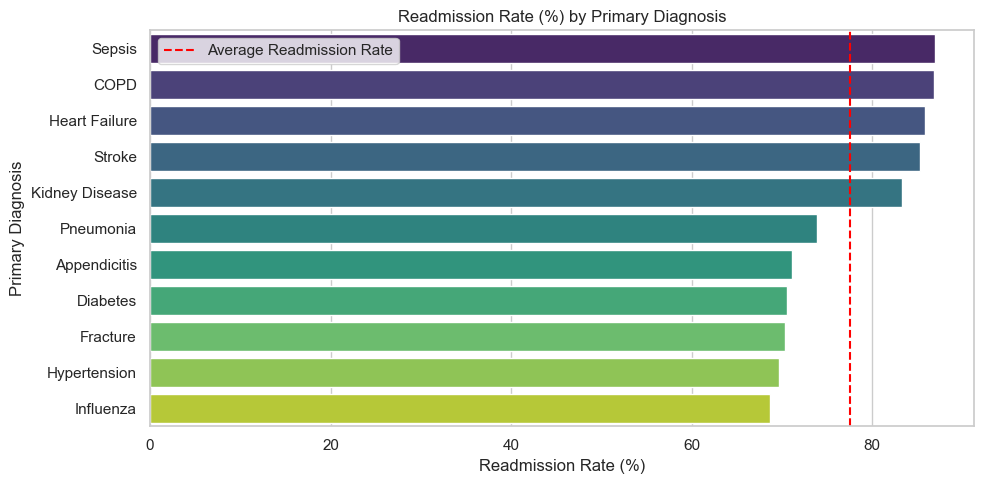

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_diagnosis, 
    x="readmission_rate_pct", 
    y="primary_diagnosis", 
    palette="viridis",
    hue="primary_diagnosis",
    legend=False
)
plt.axvline(x=df_diagnosis["readmission_rate_pct"].mean(), color="red", linestyle="--", label="Average Readmission Rate")
plt.title("Readmission Rate (%) by Primary Diagnosis")
plt.xlabel("Readmission Rate (%)")
plt.ylabel("Primary Diagnosis")
plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Machine Learning Pipeline & Hyperparameter Tuning (XGBoost)

We call `src/train.py` which executes:
- **SQL Feature Extraction** including the dynamically calculated SQL feature `stay_per_comorbidity`.
- **Pipeline Encoding**: Handling numeric and categorical variables cleanly.
- **GridSearchCV Hyperparameter Selection**: Optimizing depth, estimators, and learning rates under stratified 5-fold cross-validation.

In [13]:
from src.train import load_features_from_db, build_and_train_pipeline

# 1. Load SQL-engineered modeling features
df_features = load_features_from_db(db_path)

# 2. Run Cross-Validated Grid Search training pipeline
model_path = "../models/readmission_xgb_model.joblib"
eval_data_path = "../models/evaluation_data.joblib"
pipeline = build_and_train_pipeline(df=df_features, model_path=model_path, eval_data_path=eval_data_path)

Querying database at '../healthcare_analytics.db' for model features with SQL Feature Engineering...
Successfully loaded 8000 records with 18 features.
Numerical features (11): ['age', 'is_elderly', 'length_of_stay', 'is_high_risk_discharge', 'comorbidities_count', 'medications_count', 'followup_visits_last_year', 'prev_readmissions', 'medication_to_comorbidity_ratio', 'total_prior_interactions', 'stay_per_comorbidity']
Categorical features (7): ['gender', 'region', 'season', 'insurance_type', 'discharge_disposition', 'primary_diagnosis', 'treatment_type']
Initializing Grid Search CV (5-Fold Cross-Validation)...
Fitting model and searching parameters...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best hyperparameters found: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best CV ROC-AUC: 0.8272

OPTIMIZED XGBOOST EVALUATION METRICS (TEST SET)
Accuracy:  0.8119
ROC AUC:   0.8308

Classification Report:
              precis

---
## 5. Professional ML Performance Visualizations

To demonstrate advanced model evaluation skills, we load test predictions and plot the **ROC Curve**, **Precision-Recall Curve**, **Confusion Matrix**, and **Feature Importance**.

In [14]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, auc

# Load saved evaluation data
eval_data = joblib.load(eval_data_path)
y_test = np.array(eval_data["y_test"])
y_pred = np.array(eval_data["y_pred"])
y_pred_proba = np.array(eval_data["y_pred_proba"])
feature_names = eval_data["feature_names"]
importances = eval_data["importances"]

### A. ROC Curve and Precision-Recall Curve

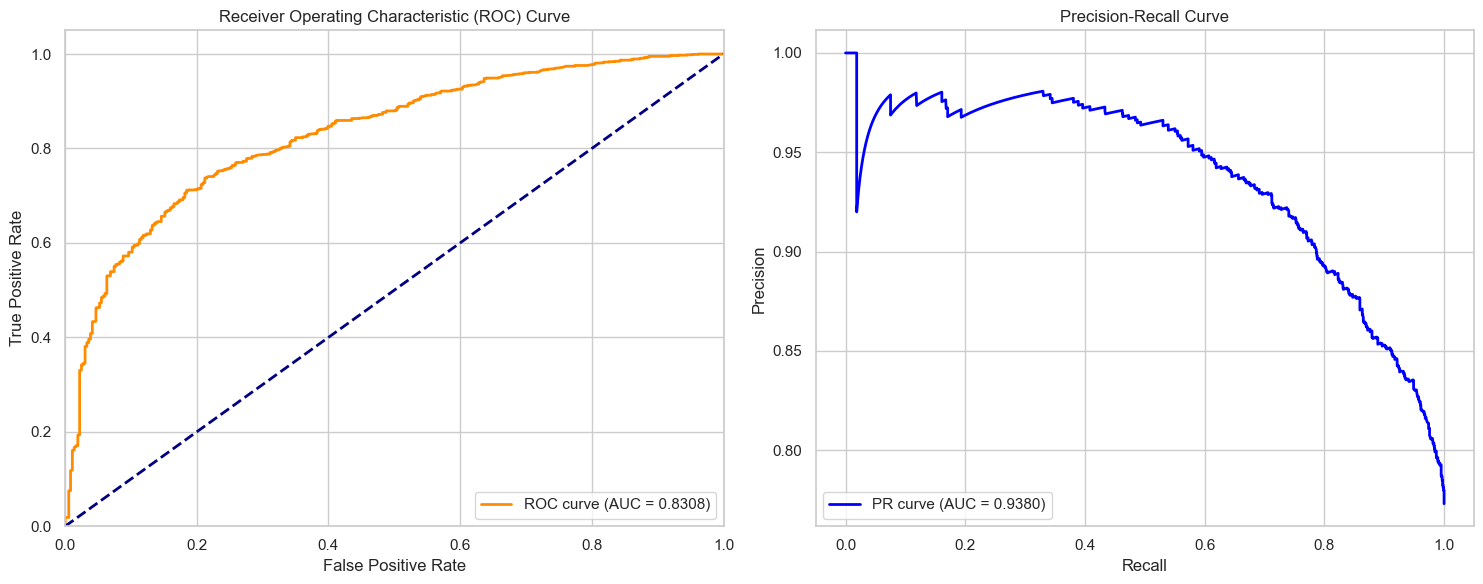

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
ax[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax[0].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("Receiver Operating Characteristic (ROC) Curve")
ax[0].legend(loc="lower right")

# PR Curve
ax[1].plot(recall, precision, color="blue", lw=2, label=f"PR curve (AUC = {pr_auc:.4f})")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall Curve")
ax[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

### B. Confusion Matrix Heatmap

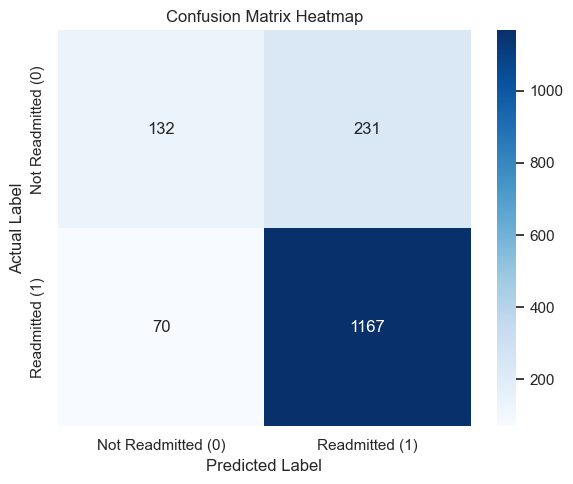

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=["Not Readmitted (0)", "Readmitted (1)"],
    yticklabels=["Not Readmitted (0)", "Readmitted (1)"]
)
plt.title("Confusion Matrix Heatmap")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

### C. Model Feature Importance
Let's see where our new clinical-domain engineered features rank in terms of XGBoost feature importance.

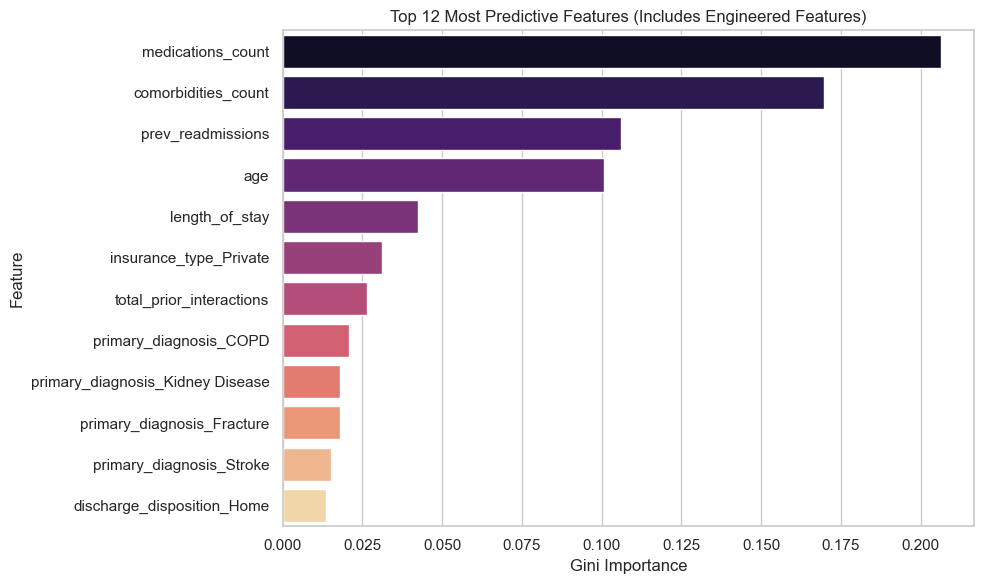

In [17]:
df_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_imp, x="Importance", y="Feature", palette="magma", hue="Feature", legend=False)
plt.title("Top 12 Most Predictive Features (Includes Engineered Features)")
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

---
## 6. Business Value & Decision Threshold Optimization

In professional ML, predicting risk is only half the battle. The final step is determining **when** to act (the decision threshold) to optimize business value (costs saved).

### 💰 Financial Model Assumptions
- **Average Cost per Readmission:** $15,000.
- **Proactive Care Intervention Cost:** $1,200.
- **Intervention Efficacy:** 30% (reduces risk by 30% for targeted patients).

We load predictions and run `src/inference.py` to search for the probability threshold that maximizes net savings.

In [18]:
from src.inference import predict_readmission_risk, optimize_threshold_for_savings

# 1. Run predictions
predictions_df = predict_readmission_risk(pipeline, df_features)

# 2. Find optimal decision threshold and get corresponding metrics
opt_data_path = "../models/threshold_opt_data.joblib"
best_threshold, best_metrics = optimize_threshold_for_savings(
    predictions_df=predictions_df, 
    save_opt_path=opt_data_path
)

Calculating readmission probabilities...
Optimizing decision threshold for maximum financial savings...
Saving threshold optimization data to '../models/threshold_opt_data.joblib'...
Optimization complete. Optimal Threshold found: 0.30 (Savings: $18,362,400.00)


### Plotting: Decision Threshold vs. Net Program Savings
We load our optimization search log to plot how changing the decision threshold impacts total net financial savings for the hospital. This illustrates direct ML business optimization!

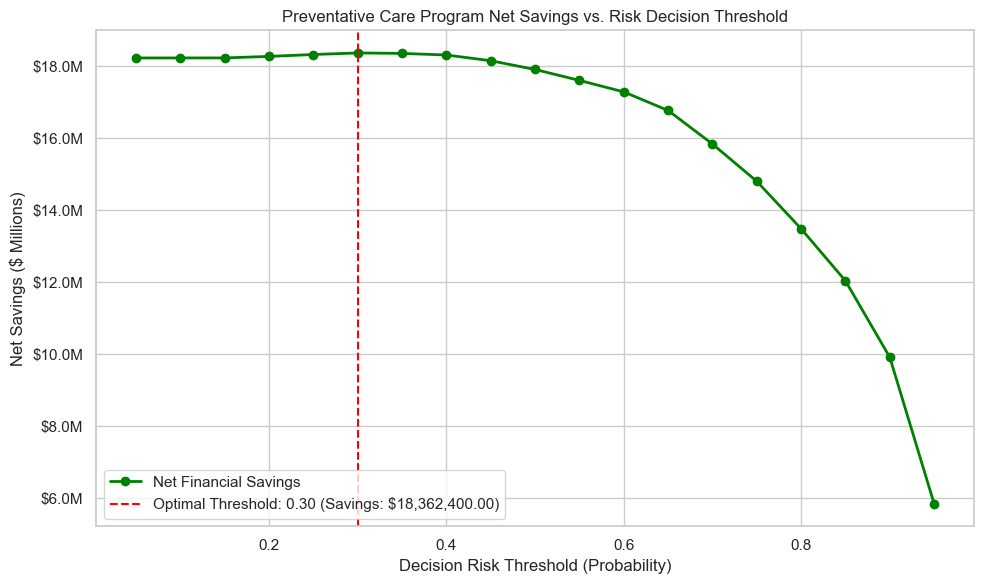

In [19]:
opt_data = joblib.load(opt_data_path)
thresholds = opt_data["thresholds"]
net_savings = opt_data["net_savings"]
best_t = opt_data["best_threshold"]
best_s = opt_data["best_savings"]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, net_savings, marker="o", color="green", lw=2, label="Net Financial Savings")
plt.axvline(x=best_t, color="red", linestyle="--", label=f"Optimal Threshold: {best_t:.2f} (Savings: ${best_s:,.2f})")
plt.title("Preventative Care Program Net Savings vs. Risk Decision Threshold")
plt.xlabel("Decision Risk Threshold (Probability)")
plt.ylabel("Net Savings ($ Millions)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x*1e-6:.1f}M"))
plt.legend()
plt.tight_layout()
plt.show()

### C. Optimized Financial Summary

In [20]:
df_roi_summary = pd.DataFrame({
    "Financial & Operational Metric": [
        "Total Patient Cohort",
        "Baseline Readmissions",
        "Baseline Total Financial Cost",
        "Patients Targeted for Care Program",
        "Percentage of Cohort Targeted",
        "Total Intervention Cost ($1,200 / patient)",
        "Expected Prevented Readmissions",
        "Gross Financial Savings",
        "Net Healthcare Savings (Profit)",
        "Return on Investment (ROI)",
        "New System Total Cost",
        "Overall Cost Reduction Percentage"
    ],
    "Value": [
        f"{best_metrics['total_patients']:,}",
        f"{best_metrics['actual_readmissions']:,}",
        f"${best_metrics['baseline_total_cost']:,.2f}",
        f"{best_metrics['patients_targeted']:,}",
        f"{best_metrics['targeting_rate_pct']:.2f}%",
        f"${best_metrics['total_intervention_cost']:,.2f}",
        f"${best_metrics['expected_prevented_readmissions']:,.2f}",
        f"${best_metrics['gross_savings']:,.2f}",
        f"${best_metrics['net_savings']:,.2f}",
        f"{best_metrics['roi_pct']:.2f}%",
        f"${best_metrics['model_total_cost']:,.2f}",
        f"{best_metrics['cost_reduction_pct']:.2f}%"
    ]
})

df_roi_summary

,Financial & Operational Metric,Value
0,Total Patient Cohort,"8,000"
1,Baseline Readmissions,"6,183"
2,Baseline Total Financial Cost,"$92,745,000.00"
3,Patients Targeted for Care Program,"7,723"
4,Percentage of Cohort Targeted,96.54%
5,"Total Intervention Cost ($1,200 / patient)","$9,267,600.00"
6,Expected Prevented Readmissions,"$1,842.00"
7,Gross Financial Savings,"$27,630,000.00"
8,Net Healthcare Savings (Profit),"$18,362,400.00"
9,Return on Investment (ROI),198.14%


## 🏁 Conclusion & Next Steps

This end-to-end pipeline demonstrates how machine learning can transition from a technical metric (ROC-AUC) into a highly impactful clinical and financial decision-making tool. By integrating relational database analytics, clinical feature engineering, robust model selection with XGBoost, and mathematical threshold optimization, this system provides healthcare organizations with a clear path to reducing readmissions while maximizing the return on investment of preventative care programs.

Future enhancements could include incorporating real-time streaming data ingestion (e.g., via Kafka) and deploying the optimal decision policy directly into electronic medical records (EMR) systems to assist clinical teams at the point of care.